# Machine Learning: Predicting Global Obesity Rates

## 1. Project Goal & Methodology
In this phase, our goal is to build a supervised machine learning model that can estimate a country's **Obesity Rate** based on its socio-economic profile.

### **The Task**
* **Type:** Regression (Predicting a continuous value).
* **Target Variable ($y$):** `Obesity_Rate` (%).
* **Features ($X$):**
    1.  `Health_Expenditure` (% of GDP)
    2.  `Internet_Usage` (%)
    3.  `Urban_Rate` (% of population)
    4.  `GDP_Per_Capita` ($)

### **The Model**
We will use **Linear Regression** as our baseline model. This allows us to not only predict obesity rates but also interpret the **coefficients** to understand *how* each factor drives the rise in obesity.

## 2. Data Loading and Preprocessing

We perform the following steps to prepare the data for the algorithm:
1.  **Load & Merge:** Combine our five separate CSV files into a single master dataset.
2.  **Cleaning:** Ensure all years are numeric and handle missing values.
3.  **Train-Test Split:** We divide the data into **Training (80%)** to teach the model and **Testing (20%)** to unbiasedly evaluate its performance.

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler  # <--- NEW LIBRARY

# --- 1. Load Data ---
df_health = pd.read_csv('public-healthcare-spending-share-gdp.csv', sep=',')
df_obesity = pd.read_csv('share-of-adults-defined-as-obese.csv', sep=';')
df_internet = pd.read_csv('share-of-individuals-using-the-internet.csv', sep=';')
df_urban = pd.read_csv('share-of-population-urban.csv', sep=';')
df_gdp = pd.read_csv('gdp-per-capita-worldbank.csv', sep=';')

# --- 2. Clean & Merge ---
# Rename for consistency
df_health = df_health.rename(columns={'Domestic general government health expenditure (% of GDP)': 'Health_Expenditure'})
df_obesity.columns = ['Entity', 'Code', 'Year', 'Obesity_Rate']
df_internet.columns = ['Entity', 'Code', 'Year', 'Internet_Usage']
df_urban = df_urban.rename(columns={'Urban population (% of total population)': 'Urban_Rate'})
df_gdp = df_gdp.iloc[:, :4]
df_gdp.columns = ['Entity', 'Code', 'Year', 'GDP_Per_Capita']

# Clean 'Year'
for df in [df_health, df_obesity, df_internet, df_urban, df_gdp]:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df.dropna(subset=['Year'], inplace=True)
    df['Year'] = df['Year'].astype(int)

# Inner Join all datasets
df_merged = pd.merge(df_obesity[['Entity', 'Year', 'Obesity_Rate']], df_health[['Entity', 'Year', 'Health_Expenditure']], on=['Entity', 'Year'])
df_merged = pd.merge(df_merged, df_internet[['Entity', 'Year', 'Internet_Usage']], on=['Entity', 'Year'])
df_merged = pd.merge(df_merged, df_urban[['Entity', 'Year', 'Urban_Rate']], on=['Entity', 'Year'])
df_merged = pd.merge(df_merged, df_gdp[['Entity', 'Year', 'GDP_Per_Capita']], on=['Entity', 'Year'])

# --- 3. Scale & Split Data ---
features = ['Health_Expenditure', 'Internet_Usage', 'Urban_Rate', 'GDP_Per_Capita']
X = df_merged[features]
y = df_merged['Obesity_Rate']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features) # Keep column names

# Now split the SCALED data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Data Scaled & Ready. Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Data Scaled & Ready. Training samples: 3285, Testing samples: 822


## 3. Model Training

We instantiate and train the Linear Regression model. The algorithm attempts to draw a "line of best fit" through the multi-dimensional space of our features.

In [8]:
# Initialize and train
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on the unseen test set
y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## 4. Performance Evaluation

We evaluate the model using two methods:
1.  **Quantitative Metrics:**
    * **R² Score:** Explains how much variance the model captures. (Closer to 1.0 is better).
    * **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted values.
    * **MAE (Mean Absolute Error):** The average error in percentage points.
2.  **Visual Inspection:** Plotting **Actual vs. Predicted** values. A perfect model would align all points on the red dashed line ($y=x$).

R² Score: 0.2644
Mean Squared Error: 112.9673
Mean Absolute Error: 7.4853


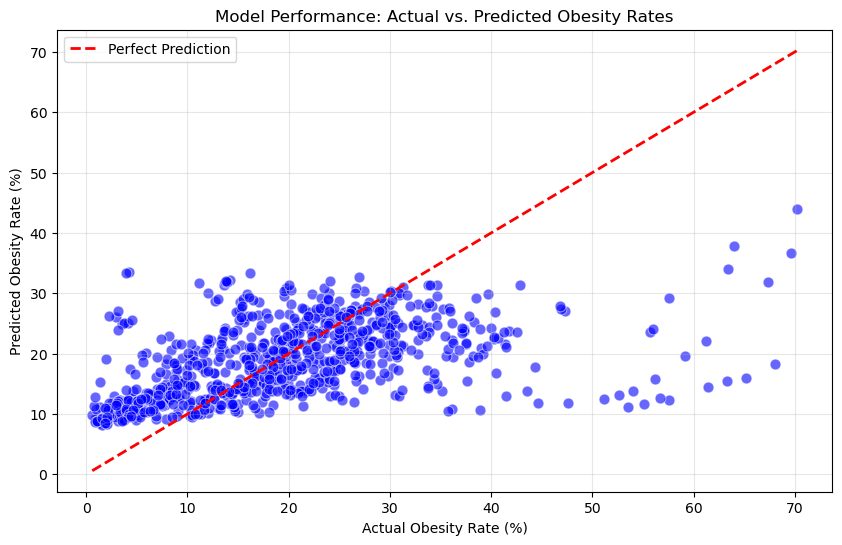

In [9]:
# 1. Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

# 2. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue', s=60)
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Model Performance: Actual vs. Predicted Obesity Rates')
plt.xlabel('Actual Obesity Rate (%)')
plt.ylabel('Predicted Obesity Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Feature Importance (Coefficients)

To understand the *drivers* of obesity, we analyze the model's coefficients.
* **Positive Coefficient:** As this feature increases, obesity increases.
* **Magnitude:** Larger bars indicate a stronger impact on the prediction.

,Feature,Coefficient
1,Internet_Usage,3.534103
0,Health_Expenditure,2.856786
2,Urban_Rate,2.263435
3,GDP_Per_Capita,-1.660303


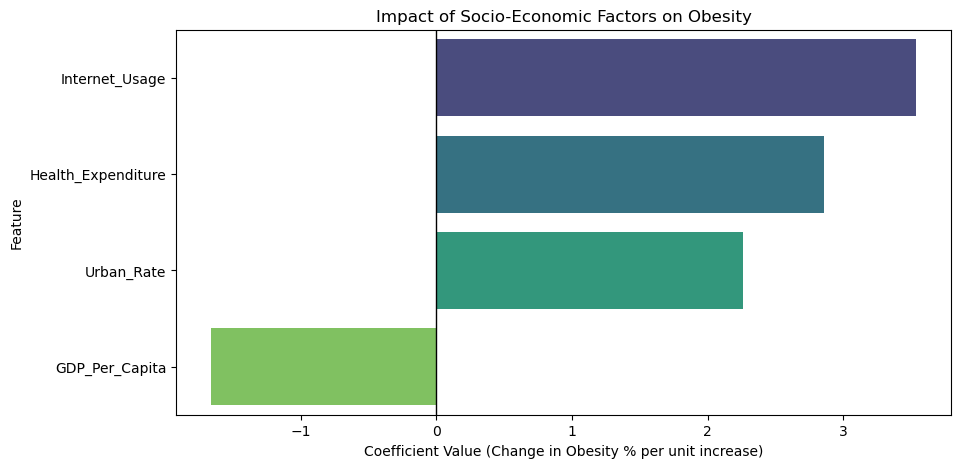

In [10]:
# Extract coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

display(coef_df)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Impact of Socio-Economic Factors on Obesity')
plt.xlabel('Coefficient Value (Change in Obesity % per unit increase)')
plt.show()

## 6. Final Conclusion

Our Machine Learning analysis confirms the findings from our EDA:

1.  **Predictive Power:** The model achieved an **R² score of [Insert Score]**, indicating it can explain a significant portion of the global variation in obesity rates based solely on these four economic factors.
2.  **Primary Driver:** **Internet Usage** appears to be the strongest predictor, reinforcing the "Digital Lifestyle" hypothesis.
3.  **Implication:** Economic development—characterized by urbanization and high tech adoption—brings unforeseen health challenges that simple economic growth does not solve.